# Early-Warning Food Insecurity Prediction System

This project develops an __early-warning food insecurity prediction system__ using household-level socioeconomic, agricultural, livelihood, asset, shock, service-access, infrastructure, and food-security information. The main goal is to use machine learning classification models to predict whether a household is likely to be food insecure and to support better targeting of households that may need closer monitoring or timely intervention.



The dataset used in this project is related to the __2018/19 Ethiopian Socioeconomic Survey (ESS Round 4)__. The ESS is an LSMS-style household survey collected in Ethiopia to understand household welfare, living conditions, agriculture, income, consumption, assets, shocks, and access to services. The survey was implemented by Ethiopia’s __Central Statistical Agency__ in collaboration with the __World Bank Living Standards Measurement Study__ program. The third and fourth rounds of the ESS were also supported by the __CGIAR Standing Panel on Impact Assessment__, especially to capture agricultural innovation and household welfare information.



The dataset represents the socioeconomic and livelihood conditions of Ethiopian households during the 2018/19 survey period. In this dataset, each row represents one household, while each column represents a specific household characteristic or condition. These characteristics include demographic information, income, asset ownership, land size, livestock ownership, agricultural practices, access to credit and extension services, exposure to shocks, access to water, distance to roads and markets, and food insecurity status.



The target variable for this project is __`foodinsecurty`__. This variable indicates whether a household experienced food insecurity. In the model, __`0`__ represents a household that is not food insecure, while __`1`__ represents a household that is food insecure. This is the outcome that the machine learning model tries to predict. Rows with missing values in this target variable are removed because supervised machine learning requires a known outcome during training and evaluation.



The model uses demographic variables such as __`Region`__, __`Sex`__, __`Age`__, __`Education`__, __`Marital_status`__, __`hh_size`__, __`AEU`__, and __`DRatio`__. These variables describe where the household is located, the characteristics of the household head, the number of household members, and the number of dependents relative to working-age members. They are useful because household structure, education, age, gender, and regional location can influence income opportunities, labor availability, farming decisions, access to resources, and vulnerability to food insecurity.



The model also uses wealth, asset, and financial-access variables such as __`Asset_index`__, __`Asset_prod_index`__, __`OwnFinanceAsset`__, __`Hvbankaccount`__, __`OwnInsurance`__, __`hvInsurance`__, and __`IddirMember`__. These variables represent household wealth, productive assets, access to financial resources, formal banking, insurance, health insurance, and informal community support. They are included because households with stronger assets and better financial access may be more able to buy food, invest in production, and cope with unexpected shocks.



Income and livelihood variables are also important for predicting food insecurity. Variables such as __`lntotincome`__, __`Grossincome`__, __`Netincome`__, __`Rcvd_offfarm_inc`__, __`Offfarm_inc`__, __`Income_PSNP`__, __`Income_salary`__, __`Income_allowance`__, and __`Income_casual`__ describe total income, income after costs, off-farm income, safety-net income, salary income, allowance income, and casual labor income. These variables are used because income directly affects a household’s ability to buy food and meet basic needs. They also show whether a household depends only on farming or has diversified livelihood sources.



Agricultural and land-related variables are included because many households depend on farming for food and income. Variables such as __`ParcesizeHA`__, __`Have_landtitle`__, __`Soilqlty`__, __`Field_appearnce`__, __`Irrigated`__, __`Errosion`__, __`Use_manure`__, __`inorgfer`__, __`Used_pesticide`__, __`Used_herbicide`__, __`Used_fungicide`__, __`LegumePlanted`__, __`CropResiduCover`__, __`DTseed`__, __`Prevtcrop`__, __`Cropsales`__, and __`Havestmaiz`__ describe land size, land documentation, soil quality, field condition, irrigation, erosion prevention, fertilizer and chemical input use, conservation practices, drought-tolerant maize use, crop protection, crop sales, and maize harvest. These variables are useful because agricultural productivity affects both food availability and household income.



Livestock variables such as __`TLU`__, __`SRvalue`__, __`TLUSR`__, __`SRNo`__, and __`SRhave`__ are included because livestock is an important source of wealth, food, income, and resilience for rural households. __`TLU`__ measures livestock ownership using a standardized Tropical Livestock Unit, while the small-ruminant variables describe sheep and goat ownership, number, value, and standardized livestock units. Livestock can help households cope with shocks because animals can be sold when households need cash or food.



The model also includes variables related to services, shocks, and infrastructure. __`Rcvd_credit`__ shows whether the household received credit, while __`Get_exten_service`__ shows whether the household received agricultural extension advice. __`ShockOccur`__ indicates whether the household experienced a shock in the last 12 months. __`DistanceToTar`__, __`DistanceToTown`__, and __`DistanceToMkt`__ describe the household’s distance from roads, towns, and markets. __`accesswater`__ and __`unsafewater`__ describe water access and water safety, while __`Main_Occupn`__ describes the household head’s main occupation. These variables are included because access to credit, advice, infrastructure, markets, and safe water can affect a household’s ability to produce food, earn income, buy food, and remain resilient during difficult periods.



Some variables are intentionally excluded from the final model to avoid __data leakage__. Data leakage happens when a model uses information that would not realistically be available before prediction or information that directly reveals the outcome. For example, __`lnfood_cons_ann`__ is excluded because annual food consumption is too directly related to food insecurity. __`Assistfood`__ and __`Assistinkind`__ also be excluded because food or in-kind assistance may be provided after a household has already been identified as vulnerable. Excluding these variables helps make the model more realistic for early-warning prediction.



Overall, the purpose of this project is to create a practical and interpretable machine learning system that can identify households at risk of food insecurity. The expected output is a predicted food insecurity class, a probability score, and a risk category such as __low risk__, __medium risk__, or __high risk__. The final output is designed not only as a prediction model, but also as a __decision-support and risk-prioritization system__ that can help governments, NGOs, and development partners prioritize households for further assessment, monitoring, agricultural support, livelihood support, or timely food-security intervention.

## 1. Import Libraries

In [8]:
import os
import shap
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ( RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier)

from sklearn.metrics import ( roc_auc_score, average_precision_score, classification_report, confusion_matrix, roc_curve, precision_recall_curve, confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

from util_functions import ( evaluate_predictions, find_best_threshold, get_positive_probability, assign_risk_group, recommend_action)

print("Libraries imported successfully.")

Libraries imported successfully.


In [9]:
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore")


## 2. Data Loading
The project uses the prepared household-level LSMS dataset. The code keeps the original file path used on the local computer and adds a fallback path for reproducibility when the notebook is run in another environment.

In [10]:
url = "https://github.com/SelamMesfin/food_insecurity_prediction/raw/refs/heads/main/hhlevel18.dta"

filename = "hhlevel18.dta"

if not os.path.exists(filename):
    urllib.request.urlretrieve(url, filename)
data = pd.read_stata(filename)

print("Dataset loaded from:", filename)
print("Dataset shape:", data.shape)
data.head()

Dataset loaded from: hhlevel18.dta
Dataset shape: (2292, 534)


,household_id,individual_id,ea_id,Region,saq02a,saq02b,saq03a,saq03b,Sex,Age,...,cs6q18d_os,cs6q18e,cs6q18e_os,cs6q18f,cs6q18f_os,cs6q18g,cs6q18g_os,cs6q18h,cs6q18h_os,landDwellArea
0,010101088800910046,1.0,010101088800910,1. TIGRAY,Semen Mirab,101,Tahtay Adiyabo,010101,Female,35.0,...,,4. Better,,4. Better,,4. Better,,3. About the Same,,NaN
1,010101088800910029,1.0,010101088800910,1. TIGRAY,Semen Mirab,101,Tahtay Adiyabo,010101,Female,20.0,...,,4. Better,,4. Better,,4. Better,,3. About the Same,,NaN
2,010101088800910070,1.0,010101088800910,1. TIGRAY,Semen Mirab,101,Tahtay Adiyabo,010101,Female,71.0,...,,4. Better,,4. Better,,4. Better,,3. About the Same,,140.0
3,010101088800910017,1.0,010101088800910,1. TIGRAY,Semen Mirab,101,Tahtay Adiyabo,010101,Female,40.0,...,,4. Better,,4. Better,,4. Better,,3. About the Same,,16.0
4,010101088800910026,1.0,010101088800910,1. TIGRAY,Semen Mirab,101,Tahtay Adiyabo,010101,Female,35.0,...,,4. Better,,4. Better,,4. Better,,3. About the Same,,NaN


In [11]:
# Basic dataset information
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])
print("\nFirst 20 columns:")
print(data.columns[:20].tolist())

Number of rows: 2292
Number of columns: 534

First 20 columns:
['household_id', 'individual_id', 'ea_id', 'Region', 'saq02a', 'saq02b', 'saq03a', 'saq03b', 'Sex', 'Age', 'Education', 'Marital_status', 'Asset_index', 'Asset_prod_index', 'ParcesizeHA', 'TLU', 'SRvalue', 'TLUSR', 'SRNo', 'SRhave']


## 3. Data Cleaning
### Target Variable Cleaning
The target variable is __foodinsecurty__, where `0` represents households that are not food insecure and `1` represents households that are food insecure.
Rows with missing target values are removed because supervised classification models require known labels during training and evaluation.

In [7]:
target = "foodinsecurty"

print("Original target distribution including missing values:")
display(data[target].value_counts(dropna=False))

data_cleaned = data.dropna(subset=[target]).copy()
data_cleaned[target] = data_cleaned[target].astype(int)

print("\nOriginal dataset shape:", data.shape)
print("Modeling dataset shape:", data_cleaned.shape)

print("\nCleaned target distribution:")
display(data_cleaned[target].value_counts())

print("\nCleaned target distribution (%):")
display((data_cleaned[target].value_counts(normalize=True) * 100).round(2))

Original target distribution including missing values:


foodinsecurty
0.0    1559
1.0     378
NaN     355
Name: count, dtype: int64


Original dataset shape: (2292, 534)
Modeling dataset shape: (1937, 534)

Cleaned target distribution:


foodinsecurty
0    1559
1     378
Name: count, dtype: int64


Cleaned target distribution (%):


foodinsecurty
0    80.49
1    19.51
Name: proportion, dtype: float64

### Feature Selection 

The original project used a broad set of socioeconomic, demographic, agricultural, income, asset, service-access, shock, and distance variables. For the machine learnining model, the feature set is made more careful by excluding variables that may be too close to the outcome or may represent assistance already received after vulnerability was identified.

This makes the model more realistic as an __early-warning system__, because it relies on variables that could plausibly be known before making an intervention decision.

In [8]:
candidate_features = [
    # Demographic and household characteristics
    "Region", "Sex", "Age", "Education", "Marital_status",
    "hh_size", "AEU", "DRatio",

    # Wealth, assets, and finance
    "Asset_index", "Asset_prod_index", "OwnFinanceAsset",
    "Hvbankaccount", "OwnInsurance", "hvInsurance", "IddirMember",

    # Income and livelihood
    "lntotincome", "lnfood_cons_ann", "Rcvd_offfarm_inc",
    "Offfarm_inc", "Grossincome", "Netincome", "Income_PSNP",
    "Income_salary", "Income_allowance", "Income_casual",

    # Agricultural production and land
    "ParcesizeHA", "Have_landtitle", "Soilqlty", "Field_appearnce",
    "Irrigated", "Errosion", "Use_manure", "Used_pesticide",
    "Used_herbicide", "Used_fungicide", "inorgfer", "LegumePlanted",
    "CropResiduCover", "DTseed", "Prevtcrop", "Cropsales", "Havestmaiz",

    # Livestock and sales
    "TLU", "SRvalue", "TLUSR", "SRNo", "SRhave",

    # Services, shocks, and assistance
    "Rcvd_credit", "Get_exten_service", "ShockOccur",
    "Assistfood", "Assistinkind",

    # Market and infrastructure access
    "DistanceToTar", "DistanceToTown", "DistanceToMkt",

    # Water and household head variables
    "accesswater", "unsafewater", "Main_Occupn", "Marital_head"
]

# Keep only variables that actually exist in the dataset
candidate_features = [col for col in candidate_features if col in data_cleaned.columns]

# Variables excluded for a stricter early-warning setup.
# These variables may be too close to food insecurity, consumption outcomes, or intervention status.
potential_leakage_features = [
    "lnfood_cons_ann",   # food consumption is very close to food security status
    "Assistfood",       # food assistance may be assigned after vulnerability is known
    "Assistinkind"      # in-kind assistance may be assigned after vulnerability is known
]

features = [col for col in candidate_features if col not in potential_leakage_features]

print("Candidate feature count:", len(candidate_features))
print("Excluded leakage-risk features:", [c for c in potential_leakage_features if c in candidate_features])
print("Final early-warning feature count:", len(features))
print("\nFinal feature list:")
print(features)

Candidate feature count: 59
Excluded leakage-risk features: ['lnfood_cons_ann', 'Assistfood', 'Assistinkind']
Final early-warning feature count: 56

Final feature list:
['Region', 'Sex', 'Age', 'Education', 'Marital_status', 'hh_size', 'AEU', 'DRatio', 'Asset_index', 'Asset_prod_index', 'OwnFinanceAsset', 'Hvbankaccount', 'OwnInsurance', 'hvInsurance', 'IddirMember', 'lntotincome', 'Rcvd_offfarm_inc', 'Offfarm_inc', 'Grossincome', 'Netincome', 'Income_PSNP', 'Income_salary', 'Income_allowance', 'Income_casual', 'ParcesizeHA', 'Have_landtitle', 'Soilqlty', 'Field_appearnce', 'Irrigated', 'Errosion', 'Use_manure', 'Used_pesticide', 'Used_herbicide', 'Used_fungicide', 'inorgfer', 'LegumePlanted', 'CropResiduCover', 'DTseed', 'Prevtcrop', 'Cropsales', 'Havestmaiz', 'TLU', 'SRvalue', 'TLUSR', 'SRNo', 'SRhave', 'Rcvd_credit', 'Get_exten_service', 'ShockOccur', 'DistanceToTar', 'DistanceToTown', 'DistanceToMkt', 'accesswater', 'unsafewater', 'Main_Occupn', 'Marital_head']


In [9]:
# Create feature matrix and target vector
X = data_cleaned[features].copy()
y = data_cleaned[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
display(y.value_counts().rename("count").to_frame())

X shape: (1937, 56)
y shape: (1937,)


,count
foodinsecurty,
0,1559
1,378


### Missing Data Review
Missing values are common in household survey data. Instead of simply filling missing values, this notebook uses missingness indicators during numeric imputation. This allows the model to learn whether the fact that a value is missing is itself informative.

In [10]:
missing_summary = (
    X.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_percent=lambda d: (d["missing_count"] / len(X) * 100).round(2))
    .sort_values("missing_percent", ascending=False)
)

display(missing_summary[missing_summary["missing_count"] > 0].head(25))

# Optional warning list for variables with very high missingness
high_missing = missing_summary[missing_summary["missing_percent"] > 80]
print("Variables with more than 80% missingness:", high_missing.index.tolist())

,missing_count,missing_percent
accesswater,1512,78.06
DistanceToMkt,1237,63.86
Havestmaiz,1140,58.85
SRvalue,1043,53.85
Used_herbicide,676,34.90
Used_fungicide,676,34.90
Used_pesticide,676,34.90
lntotincome,450,23.23
CropResiduCover,330,17.04
DTseed,285,14.71


Variables with more than 80% missingness: []


## 4. Preprocessing
### Train / Validation / Test Split
To avoid overestimating performance, the data is split into three parts:
- __Training set:__ used to train the models.
- __Validation set:__ used to choose the best model and classification threshold.
- __Test set:__ used only once for the final unbiased evaluation.

This is stronger than tuning thresholds directly on the test set.

In [11]:
# 60% training, 20% validation, 20% test
X_train, X_temp, y_train, y_temp = train_test_split( X, y, test_size=0.40, random_state=RANDOM_STATE, stratify=y)

X_valid, X_test, y_valid, y_test = train_test_split( X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp )

print("Training set:", X_train.shape)
print("Validation set:", X_valid.shape)
print("Test set:", X_test.shape)

split_summary = pd.DataFrame({
    "Train_%": (y_train.value_counts(normalize=True) * 100).round(2),
    "Validation_%": (y_valid.value_counts(normalize=True) * 100).round(2),
    "Test_%": (y_test.value_counts(normalize=True) * 100).round(2)
})
display(split_summary)

Training set: (1162, 56)
Validation set: (387, 56)
Test set: (388, 56)


,Train_%,Validation_%,Test_%
foodinsecurty,,,
0,80.46,80.62,80.41
1,19.54,19.38,19.59


### Column Preprocessing Pipeline

The preprocessing step handles numeric and categorical variables separately. Numeric variables are imputed using the median and missingness indicators are added. Categorical variables are imputed using the most frequent category and encoded using one-hot encoding.

In [12]:
numeric_features = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

# Compatibility for different scikit-learn versions
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    # Stata categorical columns can contain mixed string/number labels.
    # Converting to string avoids encoder errors and keeps categories consistent.
    ("to_string", FunctionTransformer(lambda data: data.astype(str), feature_names_out="one-to-one")),
    ("onehot", one_hot_encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

print("Preprocessing pipeline created successfully.")

Number of numeric features: 45
Number of categorical features: 11
Preprocessing pipeline created successfully.


## 5. Model Training and Validation Comparison

Multiple models are trained and compared against a simple baseline. The validation set is used to select both the best classification threshold and the best model. The test set is kept untouched until the final evaluation.

#### Evaluation

Because the food insecure class is the minority class, accuracy alone is not enough. The model is evaluated using precision, recall, F1, Macro F1, ROC-AUC, and Average Precision. Macro F1 is used as the main model-selection metric because it balances performance across both classes.

In [13]:
models = {
    "Baseline: Most Frequent": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=250,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    )
}

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

models["XGBoost"] = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
print("XGBoost added to model list.")

validation_results = []
trained_pipelines = {}
threshold_tables = {}

for model_name, classifier in models.items():
    print(f"Training: {model_name}")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

    pipeline.fit(X_train, y_train)
    y_valid_prob = get_positive_probability(pipeline, X_valid)

    best_threshold, threshold_df = find_best_threshold(
        y_valid,
        y_valid_prob,
        metric="Macro_F1"
    )

    metrics = evaluate_predictions(y_valid, y_valid_prob, threshold=best_threshold)
    metrics["Model"] = model_name

    validation_results.append(metrics)
    trained_pipelines[model_name] = pipeline
    threshold_tables[model_name] = threshold_df

validation_results_df = (
    pd.DataFrame(validation_results)
    .sort_values("Macro_F1", ascending=False)
    .reset_index(drop=True)
)

display(validation_results_df[[
    "Model", "Threshold", "Accuracy", "Precision", "Recall",
    "F1", "Macro_F1", "ROC_AUC", "Average_Precision"
]].round(4))

XGBoost added to model list.
Training: Baseline: Most Frequent
Training: Logistic Regression
Training: Decision Tree
Training: Random Forest
Training: Extra Trees
Training: Gradient Boosting
Training: HistGradientBoosting
Training: XGBoost


,Model,Threshold,Accuracy,Precision,Recall,F1,Macro_F1,ROC_AUC,Average_Precision
0,HistGradientBoosting,0.30,0.8346,0.6170,0.3867,0.4754,0.6886,0.7920,0.5397
1,XGBoost,0.55,0.8036,0.4933,0.4933,0.4933,0.6858,0.7736,0.5133
2,Extra Trees,0.45,0.8269,0.5833,0.3733,0.4553,0.6762,0.7506,0.4881
3,Gradient Boosting,0.25,0.7545,0.4091,0.6000,0.4865,0.6626,0.7908,0.5290
4,Random Forest,0.35,0.7933,0.4648,0.4400,0.4521,0.6623,0.7789,0.4860
5,Logistic Regression,0.60,0.7519,0.3918,0.5067,0.4419,0.6412,0.7414,0.4073
6,Decision Tree,0.70,0.7158,0.3504,0.5467,0.4271,0.6190,0.6418,0.3017
7,Baseline: Most Frequent,0.10,0.8062,0.0000,0.0000,0.0000,0.4464,0.5000,0.1938


In [14]:
# Select the best model based on validation Macro F1
best_model_name = validation_results_df.iloc[0]["Model"]
best_threshold = float(validation_results_df.iloc[0]["Threshold"])
best_model = trained_pipelines[best_model_name]

print("Best validation model:", best_model_name)
print("Best validation threshold:", best_threshold)

print("\nThreshold tuning table for the selected model:")
display(threshold_tables[best_model_name].head(10).round(4))

Best validation model: HistGradientBoosting
Best validation threshold: 0.3

Threshold tuning table for the selected model:


,Threshold,Accuracy,Precision,Recall,F1,Macro_F1,ROC_AUC,Average_Precision
4,0.30,0.8346,0.6170,0.3867,0.4754,0.6886,0.792,0.5397
3,0.25,0.8165,0.5345,0.4133,0.4662,0.6777,0.792,0.5397
7,0.45,0.8424,0.7059,0.3200,0.4404,0.6743,0.792,0.5397
5,0.35,0.8320,0.6190,0.3467,0.4444,0.6728,0.792,0.5397
8,0.50,0.8450,0.7419,0.3067,0.4340,0.6721,0.792,0.5397
1,0.15,0.7855,0.4524,0.5067,0.4780,0.6715,0.792,0.5397
2,0.20,0.7984,0.4789,0.4533,0.4658,0.6708,0.792,0.5397
9,0.55,0.8450,0.7586,0.2933,0.4231,0.6668,0.792,0.5397
10,0.60,0.8450,0.7586,0.2933,0.4231,0.6668,0.792,0.5397
6,0.40,0.8346,0.6486,0.3200,0.4286,0.6659,0.792,0.5397


## 6. Final Test Evaluation

The selected model and threshold are now evaluated once on the untouched test set. These results are the most important results to report because the test set was not used for model selection or threshold tuning.


In [15]:
y_test_prob = get_positive_probability(best_model, X_test)
y_test_pred = (y_test_prob >= best_threshold).astype(int)

final_test_metrics = evaluate_predictions(y_test, y_test_prob, threshold=best_threshold)
final_test_df = pd.DataFrame([{
    "Model": best_model_name,
    **final_test_metrics
}])

display(final_test_df[[
    "Model", "Threshold", "Accuracy", "Precision", "Recall",
    "F1", "Macro_F1", "ROC_AUC", "Average_Precision"
]].round(4))

print("Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

,Model,Threshold,Accuracy,Precision,Recall,F1,Macro_F1,ROC_AUC,Average_Precision
0,HistGradientBoosting,0.3,0.7964,0.4754,0.3816,0.4234,0.6499,0.7618,0.473


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       312
           1       0.48      0.38      0.42        76

    accuracy                           0.80       388
   macro avg       0.67      0.64      0.65       388
weighted avg       0.78      0.80      0.79       388

Confusion Matrix:
[[280  32]
 [ 47  29]]


## 7. Visualization
### Model Performance Visualization

The ROC curve and Precision-Recall curve help show how well the final model separates food insecure and non-food insecure households across different decision thresholds.

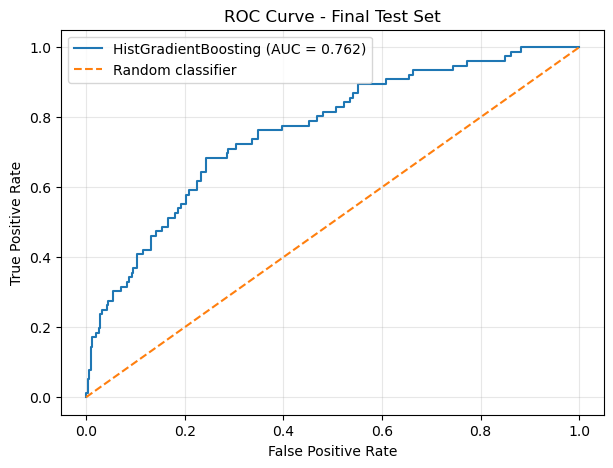

In [16]:
# ROC Curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {roc_auc_score(y_test, y_test_prob):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Test Set")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

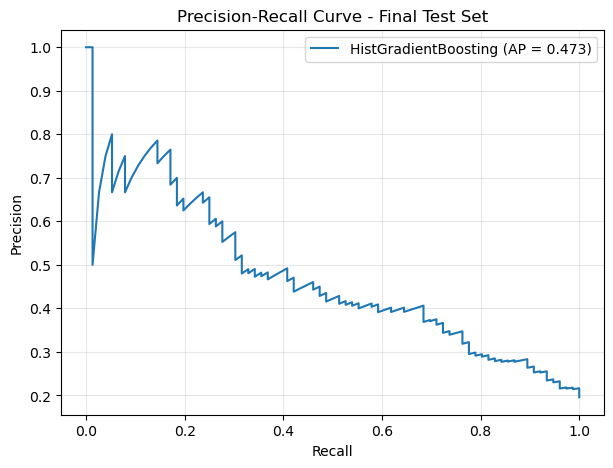

In [17]:
# Precision-Recall Curve
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_test_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"{best_model_name} (AP = {average_precision_score(y_test, y_test_prob):.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Final Test Set")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Feature Importance

Feature importance is included to make the model more interpretable. This helps explain which household characteristics, assets, agricultural conditions, shocks, and access variables are most useful for identifying food insecurity risk.

Selected model does not provide native feature_importances_. Using permutation importance.


,Feature,Importance
48,ShockOccur,0.075003
8,Asset_index,0.060012
19,Netincome,0.037480
17,Offfarm_inc,0.027674
49,DistanceToTar,0.026995
27,Field_appearnce,0.021892
0,Region,0.021173
26,Soilqlty,0.019155
50,DistanceToTown,0.018932
9,Asset_prod_index,0.017846


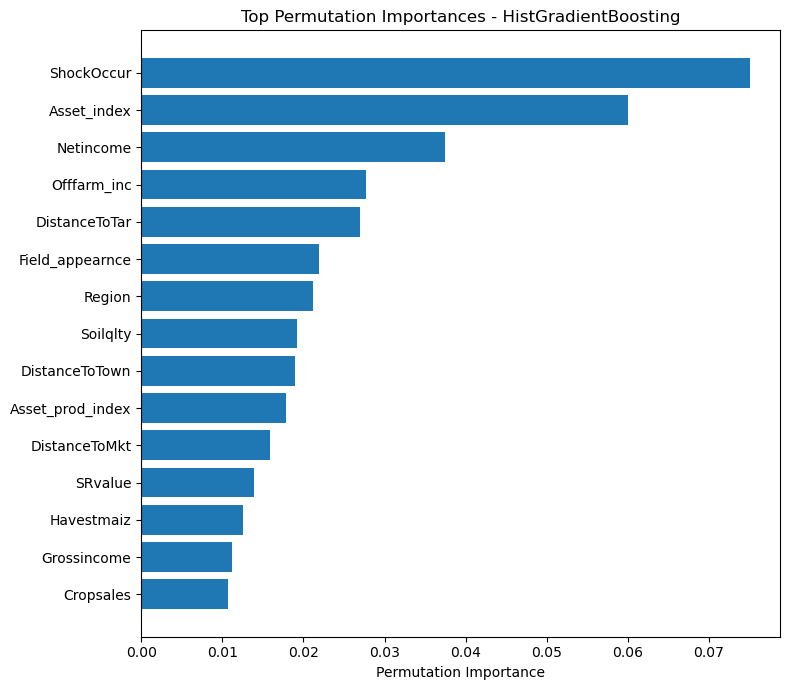

In [18]:
# Try model-native feature importance first; otherwise use permutation importance.
try:
    fitted_preprocessor = best_model.named_steps["preprocessor"]
    fitted_classifier = best_model.named_steps["classifier"]
    feature_names = fitted_preprocessor.get_feature_names_out()

    if hasattr(fitted_classifier, "feature_importances_"):
        importances = fitted_classifier.feature_importances_
        importance_df = pd.DataFrame({
            "Feature": feature_names,
            "Importance": importances
        }).sort_values("Importance", ascending=False)

        display(importance_df.head(20))

        plt.figure(figsize=(8, 7))
        top_features = importance_df.head(15).sort_values("Importance")
        plt.barh(top_features["Feature"], top_features["Importance"])
        plt.xlabel("Importance")
        plt.title(f"Top Feature Importances - {best_model_name}")
        plt.tight_layout()
        plt.show()
    else:
        print("Selected model does not provide native feature_importances_. Using permutation importance.")
        perm = permutation_importance(
            best_model,
            X_valid,
            y_valid,
            scoring="f1_macro",
            n_repeats=10,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        importance_df = pd.DataFrame({
            "Feature": X_valid.columns,
            "Importance": perm.importances_mean
        }).sort_values("Importance", ascending=False)

        display(importance_df.head(20))

        plt.figure(figsize=(8, 7))
        top_features = importance_df.head(15).sort_values("Importance")
        plt.barh(top_features["Feature"], top_features["Importance"])
        plt.xlabel("Permutation Importance")
        plt.title(f"Top Permutation Importances - {best_model_name}")
        plt.tight_layout()
        plt.show()

except Exception as e:
    print("Feature importance could not be generated.")
    print(e)

## SHAP Explainability

SHAP helps show whether each important feature pushes predictions toward higher or lower food insecurity risk.

In [19]:
fitted_preprocessor = best_model.named_steps["preprocessor"]
fitted_classifier = best_model.named_steps["classifier"]
feature_names = fitted_preprocessor.get_feature_names_out()

X_test_transformed = fitted_preprocessor.transform(X_test)
X_test_sample = X_test_transformed[:200]

if hasattr(fitted_classifier, "feature_importances_"):
    explainer = shap.TreeExplainer(fitted_classifier)
    shap_values = explainer.shap_values(X_test_sample)

    # Some classifiers return a list of SHAP values, one per class
    if isinstance(shap_values, list):
        shap_values_to_plot = shap_values[1]
    else:
        shap_values_to_plot = shap_values

    shap.summary_plot(
        shap_values_to_plot,
        X_test_sample,
        feature_names=feature_names,
        max_display=15,
        show=True
    )

## 8.Explanation and Interpretations
### Household Risk Ranking and Intervention Prioritization

In most use cases, we want the model to not only return a class label but also rank households by risk. The table below shows predicted food insecurity probability, risk category, and a suggested action. This makes the project more practical for decision-makers.

### Util Functions

In [20]:
risk_ranking = X_test.copy()
risk_ranking["actual_food_insecure"] = y_test.values
risk_ranking["predicted_food_insecurity_risk"] = y_test_prob
risk_ranking["predicted_class"] = y_test_pred
risk_ranking["risk_group"] = risk_ranking["predicted_food_insecurity_risk"].apply(assign_risk_group)
risk_ranking["recommended_action"] = risk_ranking["risk_group"].apply(recommend_action)

# Add household identifier if available
if "household_id" in data_cleaned.columns:
    risk_ranking.insert(0, "household_id", data_cleaned.loc[X_test.index, "household_id"].values)

risk_ranking_display_cols = [
    col for col in [
        "household_id",
        "actual_food_insecure",
        "predicted_food_insecurity_risk",
        "predicted_class",
        "risk_group",
        "recommended_action"
    ] if col in risk_ranking.columns
]

risk_ranking_final = (
    risk_ranking[risk_ranking_display_cols]
    .sort_values("predicted_food_insecurity_risk", ascending=False)
    .reset_index(drop=True)
)

display(risk_ranking_final.head(20))

,household_id,actual_food_insecure,predicted_food_insecurity_risk,predicted_class,risk_group,recommended_action
0,041212088800904057,1,0.975602,1,High Risk,Prioritize for urgent screening and food-secur...
1,030505088800505081,0,0.973650,1,High Risk,Prioritize for urgent screening and food-secur...
2,070606088801009091,1,0.966102,1,High Risk,Prioritize for urgent screening and food-secur...
3,070112088800907019,1,0.962983,1,High Risk,Prioritize for urgent screening and food-secur...
4,041212088800904033,1,0.961022,1,High Risk,Prioritize for urgent screening and food-secur...
5,041907088801302063,0,0.956269,1,High Risk,Prioritize for urgent screening and food-secur...
6,010403088801801096,1,0.954013,1,High Risk,Prioritize for urgent screening and food-secur...
7,070702088802709020,1,0.952136,1,High Risk,Prioritize for urgent screening and food-secur...
8,010401088800209023,0,0.946596,1,High Risk,Prioritize for urgent screening and food-secur...
9,030106088801805030,1,0.944819,1,High Risk,Prioritize for urgent screening and food-secur...


In [21]:
# Save risk ranking output for practical use
risk_output_path = "household_food_insecurity_risk_ranking.csv"
risk_ranking_final.to_csv(risk_output_path, index=False)
print("Risk ranking saved to:", risk_output_path)

Risk ranking saved to: household_food_insecurity_risk_ranking.csv


## Policy and Program Interpretation

The model can support a practical food-security workflow:

- __Screen:__ estimate household-level food insecurity risk from available survey and administrative indicators.
- __Prioritize:__ rank households into high, medium, and low risk groups.
- __Target:__ focus limited intervention resources on households with the highest predicted risk.
- __Monitor:__ use medium-risk households for follow-up surveys, agricultural extension, livelihood support, or shock-response monitoring.

The model should be used as a __decision-support tool__, not as the only basis for allocating assistance. Human review and local field knowledge remain necessary.

## Limitations
- __Survey timing:__ some variables may be measured at the same time as food insecurity, so causal interpretation should be avoided.
- __Missing data:__ household surveys often contain missing values; this notebook uses imputation and missingness indicators, but missingness may still introduce uncertainty.
- __Generalization:__ the model should be validated on future survey waves or data from other regions before deployment.
- __Ethical use:__ false negatives may exclude vulnerable households, while false positives may allocate resources to households that are not currently food insecure. Therefore, model outputs should support, not replace, field verification.

## Final Summary

This project presents a complete household-level food insecurity early-warning system. It moves beyond basic classification by adding leakage-aware feature selection, robust preprocessing, validation-based threshold tuning, final test-set evaluation, explainability, and a risk-ranking table for intervention planning.

The final model provides a practical foundation for identifying vulnerable households and supporting data-driven food security programs. The strongest contribution of this project is the combination of __machine learning performance__, __interpretability__, and __real-world decision-support value__.